# Nivel 3 — Solución Programática Avanzada: Integración de Racionalidad Formal
Este notebook representa la consolidación final del sistema inteligente de orquestación logística. Sobre la arquitectura base desarrollada en LangChain y Gemini, este nivel añade un componente de **Racionalidad Formal** basado en un modelo de **Lógica Difusa (Fuzzy Logic)** y un marco de **Evaluación Cuantitativa** de métricas de rendimiento. El objetivo es optimizar la toma de decisiones transaccionales y evaluar con rigor científico la precisión del sistema ante solicitudes complejas en lenguaje natural.

### Pilares del Sistema Avanzado
1. **Capa Cognitiva:** Extracción sintáctica estructurada mediante `gemini-2.5-flash` y LangChain.
2. **Racionalidad Formal:** Módulo difuso para evaluar la prioridad o criticidad del despacho según niveles de stock y volumen de pedido.
3. **Capa Transaccional:** Persistencia relacional simulada mediante estructuras de datos en Pandas (`Stock`, `Pedidos`, `Facturas`).
4. **Validación Experimental:** Matriz de confusión y cálculo de métricas ($Precision$, $Recall$, $F1\text{-}Score$) sobre un dataset de prueba.

## 1. Configuración del Entorno y Carga de Dependencias
En este bloque se preparan las herramientas del ecosistema de ejecución. Además de los componentes fundamentales para el bot de Telegram y los modelos de lenguaje de Google, se instalan y configuran librerías científicas y de cálculo matricial necesarias para el modelado difuso y la computación estadística de las métricas de evaluación transaccional. Asimismo, se realiza la inyección segura de las credenciales de autenticación mediante variables de entorno del sistema.

In [2]:
!pip install -q -U langchain langchain-core langchain-google-genai python-telegram-bot pandas==2.2.2 openpyxl pydantic==2.12.3 scikit-fuzzy
print("✅ Dependencias instaladas")

✅ Dependencias instaladas


In [3]:
import os

try:
    from google.colab import userdata
    os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
    TELEGRAM_BOT_TOKEN = userdata.get("TELEGRAM_BOT_TOKEN")
    print("✅ GOOGLE_API_KEY cargada desde Colab Secrets")
    print("✅ TELEGRAM_BOT_TOKEN cargado desde Colab Secrets")
except Exception:
    TELEGRAM_BOT_TOKEN = os.getenv("TELEGRAM_BOT_TOKEN", "")
    if os.getenv("GOOGLE_API_KEY"):
        print("✅ GOOGLE_API_KEY cargada desde variables de entorno")
    else:
        print("⚠️ Falta GOOGLE_API_KEY")
    if TELEGRAM_BOT_TOKEN:
        print("✅ TELEGRAM_BOT_TOKEN cargado desde variables de entorno")
    else:
        print("⚠️ Falta TELEGRAM_BOT_TOKEN")

✅ GOOGLE_API_KEY cargada desde Colab Secrets
✅ TELEGRAM_BOT_TOKEN cargado desde Colab Secrets


## 2. Persistencia de Datos y Estructuración de Esquemas Relacionales
En esta sección se inicializa la base de conocimiento operativa del sistema mediante la lectura automatizada del archivo maestro `Registros.xlsx`. Utilizando la librería `Pandas`, la información es parseada en tres flujos independientes de almacenamiento indexado: inventario físico (`Stock`), órdenes de compra procesadas (`Pedidos`) e histórico contable de transacciones (`Facturas`), asegurando la integridad referencial durante las mutaciones de estado de las herramientas.

In [4]:
from pathlib import Path
import pandas as pd
from datetime import datetime
from uuid import uuid4

EXCEL_PATH = Path("Registros.xlsx")
TZ_LABEL = "America/Bogota"

assert EXCEL_PATH.exists(), f"No se encontró {EXCEL_PATH.resolve()}"
print(f"✅ Archivo encontrado: {EXCEL_PATH.resolve()}")

✅ Archivo encontrado: /content/Registros.xlsx


In [5]:
stock_df = pd.read_excel(EXCEL_PATH, sheet_name="Stock")
pedidos_df = pd.read_excel(EXCEL_PATH, sheet_name="Pedidos")
facturas_df = pd.read_excel(EXCEL_PATH, sheet_name="Facturas")

print("Stock:", stock_df.shape)
print("Pedidos:", pedidos_df.shape)
print("Facturas:", facturas_df.shape)

stock_df.head()

Stock: (30, 4)
Pedidos: (0, 11)
Facturas: (0, 6)


,producto_id,descripcion_producto,stock,precio_unitario
0,PROD-001,Caja de guantes industriales talla M,120,18000
1,PROD-002,Cinta de embalaje 48 mm x 100 m,85,9500
2,PROD-003,Rollo de etiqueta térmica 100x100,40,32000
3,PROD-004,Lector de código de barras inalámbrico,12,145000
4,PROD-005,Impresora térmica de etiquetas,6,420000


## 3. Funciones auxiliares para Excel

Estas funciones simulan las tools del agente sobre el archivo `Registros.xlsx`.

In [6]:
EXPECTED_PEDIDOS = [
    "order_id", "cliente", "chat_id", "producto_id", "descripcion_producto",
    "cantidad", "estado", "stock", "fecha_pedido", "fecha_despacho", "total"
]
EXPECTED_STOCK = ["producto_id", "descripcion_producto", "stock", "precio_unitario"]
EXPECTED_FACTURAS = ["factura_id", "order_id", "cliente", "monto_total", "fecha_factura", "estado_factura"]


def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def load_sheets():
    stock = pd.read_excel(EXCEL_PATH, sheet_name="Stock")
    pedidos = pd.read_excel(EXCEL_PATH, sheet_name="Pedidos")
    facturas = pd.read_excel(EXCEL_PATH, sheet_name="Facturas")

    for col in EXPECTED_PEDIDOS:
        if col not in pedidos.columns:
            pedidos[col] = ""
    for col in EXPECTED_STOCK:
        if col not in stock.columns:
            stock[col] = ""
    for col in EXPECTED_FACTURAS:
        if col not in facturas.columns:
            facturas[col] = ""

    return stock[EXPECTED_STOCK].copy(), pedidos[EXPECTED_PEDIDOS].copy(), facturas[EXPECTED_FACTURAS].copy()


def save_sheets(stock, pedidos, facturas):
    with pd.ExcelWriter(EXCEL_PATH, engine="openpyxl", mode="w") as writer:
        pedidos.to_excel(writer, sheet_name="Pedidos", index=False)
        stock.to_excel(writer, sheet_name="Stock", index=False)
        facturas.to_excel(writer, sheet_name="Facturas", index=False)

## [Avanzado] Módulo de Racionalidad Formal: Sistema de Inferencia Difuso
Este bloque implementa el núcleo matemático de racionalidad formal exigido en el Nivel 3. A través de funciones de membresía triangulares y trapezoidales, transformamos variables continuas del negocio (como el nivel de inventario remanente y la urgencia de la cantidad solicitada) en conjuntos difusos. El motor evalúa un conjunto de reglas condicionales heurísticas para determinar analíticamente el nivel de criticidad o viabilidad del pedido, permitiendo una asignación de recursos más inteligente que un condicional booleano binario.

In [7]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

stock_u = np.arange(0, 201, 1)
cantidad_u = np.arange(0, 21, 1)
valor_u = np.arange(0, 1000001, 1000)
prioridad_u = np.arange(0, 101, 1)

stock_var = ctrl.Antecedent(stock_u, 'stock')
cantidad_var = ctrl.Antecedent(cantidad_u, 'cantidad')
valor_var = ctrl.Antecedent(valor_u, 'valor')
prioridad_var = ctrl.Consequent(prioridad_u, 'prioridad')

stock_var['bajo'] = fuzz.trapmf(stock_var.universe, [0, 0, 10, 40])
stock_var['medio'] = fuzz.trimf(stock_var.universe, [20, 80, 140])
stock_var['alto'] = fuzz.trapmf(stock_var.universe, [100, 140, 200, 200])

cantidad_var['baja'] = fuzz.trapmf(cantidad_var.universe, [0, 0, 2, 5])
cantidad_var['media'] = fuzz.trimf(cantidad_var.universe, [3, 7, 12])
cantidad_var['alta'] = fuzz.trapmf(cantidad_var.universe, [9, 13, 20, 20])

valor_var['bajo'] = fuzz.trapmf(valor_var.universe, [0, 0, 50000, 180000])
valor_var['medio'] = fuzz.trimf(valor_var.universe, [120000, 300000, 550000])
valor_var['alto'] = fuzz.trapmf(valor_var.universe, [450000, 650000, 1000000, 1000000])

prioridad_var['baja'] = fuzz.trimf(prioridad_var.universe, [0, 0, 40])
prioridad_var['media'] = fuzz.trimf(prioridad_var.universe, [30, 50, 70])
prioridad_var['alta'] = fuzz.trimf(prioridad_var.universe, [60, 100, 100])

rule1 = ctrl.Rule(stock_var['alto'] & cantidad_var['baja'], prioridad_var['alta'])
rule2 = ctrl.Rule(stock_var['medio'] & valor_var['alto'], prioridad_var['alta'])
rule3 = ctrl.Rule(stock_var['bajo'] & cantidad_var['alta'], prioridad_var['baja'])
rule4 = ctrl.Rule(stock_var['bajo'] & valor_var['alto'], prioridad_var['media'])
rule5 = ctrl.Rule(cantidad_var['media'] & valor_var['medio'], prioridad_var['media'])
rule6 = ctrl.Rule(stock_var['alto'] & valor_var['alto'], prioridad_var['alta'])
rule7 = ctrl.Rule(stock_var['medio'] & cantidad_var['baja'], prioridad_var['alta'])
rule8 = ctrl.Rule(stock_var['alto'] & cantidad_var['alta'], prioridad_var['media'])
rule9 = ctrl.Rule(stock_var['bajo'] & valor_var['bajo'], prioridad_var['baja'])

priority_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9
])

def priority_label(score: float) -> str:
    if score < 40:
        return "BAJA"
    elif score < 70:
        return "MEDIA"
    return "ALTA"

def fuzzy_priority(stock: int, cantidad: int, valor_total: float) -> dict:
    sim = ctrl.ControlSystemSimulation(priority_ctrl)
    sim.input['stock'] = max(0, min(200, int(stock)))
    sim.input['cantidad'] = max(0, min(20, int(cantidad)))
    sim.input['valor'] = max(0, min(1000000, float(valor_total)))
    sim.compute()
    score = float(sim.output['prioridad'])
    return {
        "prioridad_score": round(score, 2),
        "prioridad_label": priority_label(score)
    }

print("✅ Sistema difuso cargado")

✅ Sistema difuso cargado


In [8]:
print(fuzzy_priority(stock=120, cantidad=2, valor_total=64000))
print(fuzzy_priority(stock=5, cantidad=1, valor_total=890000))
print(fuzzy_priority(stock=0, cantidad=4, valor_total=120000))

{'prioridad_score': 84.44, 'prioridad_label': 'ALTA'}
{'prioridad_score': 50.0, 'prioridad_label': 'MEDIA'}
{'prioridad_score': 15.85, 'prioridad_label': 'BAJA'}


## 4. Diseño Funcional de Herramientas de Interacción (Tools)
Para dotar al agente de la capacidad de ejecutar efectos secundarios en el entorno logístico, encapsulamos las reglas operativas de negocio en funciones puras de Python. Estas funciones actúan como las compuertas de lectura y modificación del archivo Excel, proveyendo métodos deterministas para la verificación inmediata de disponibilidad física de bienes, asentamiento e indexación de pedidos despachados, y recuperación histórica de estados de entrega mediante el identificador único de sesión del cliente.

In [9]:
from typing import Optional, Literal
from pydantic import BaseModel, Field

class IntentOutput(BaseModel):
    intencion: Literal["crear_pedido", "consultar_estado", "saludo", "otro"]
    order_id: str = ""
    producto_id: str = ""
    cantidad: int = 0


def get_stock(producto_id: str) -> dict:
    stock_df, _, _ = load_sheets()
    row = stock_df[stock_df["producto_id"].astype(str).str.upper() == producto_id.upper()]
    if row.empty:
        return {"found": False, "producto_id": producto_id, "mensaje": "Producto no encontrado"}
    r = row.iloc[0]
    return {
        "found": True,
        "producto_id": str(r["producto_id"]),
        "descripcion_producto": str(r["descripcion_producto"]),
        "stock": int(r["stock"]),
        "precio_unitario": float(r["precio_unitario"]),
    }


def createorder(cliente: str, chat_id: str, producto_id: str, cantidad: int) -> dict:
    stock_df, pedidos, facturas = load_sheets() # Use stock_df for the DataFrame
    info = get_stock(producto_id)
    order_id = f"{cliente}{str(uuid4())[:8]}"
    fecha_pedido = now_str()

    if not info["found"]:
        newrow = {
            "orderid": order_id,
            "cliente": cliente,
            "chat_id": str(chat_id),
            "producto_id": producto_id,
            "descripcion_producto": "",
            "cantidad": int(cantidad),
            "estado": "PRODUCTO_NO_ENCONTRADO",
            "stock": 0,
            "fecha_pedido": fecha_pedido,
            "fecha_despacho": "",
            "total": 0,
        }
        pedidos = pd.concat([pedidos, pd.DataFrame([newrow])], ignore_index=True)
        save_sheets(stock_df, pedidos, facturas) # Pass stock_df
        return {
            "ok": False,
            "order_id": order_id,
            "estado": "PRODUCTO_NO_ENCONTRADO",
            "mensaje": "Producto no encontrado"
        }

    current_stock_count = int(info["stock"]) # Rename to avoid shadowing the DataFrame
    precio_unitario = float(info["precio_unitario"])
    total = int(cantidad * precio_unitario)

    if current_stock_count >= cantidad:
        stock_df.loc[ # Use stock_df here
            stock_df["producto_id"].astype(str).str.upper() == producto_id.upper(),
            "stock"
        ] = current_stock_count - cantidad # Update the DataFrame with the new stock count

        fecha_despacho = now_str()
        prioridad = fuzzy_priority(
            stock=current_stock_count, # Use current_stock_count
            cantidad=int(cantidad),
            valor_total=float(total)
        )

        newrow = {
            "order_id": order_id,
            "cliente": cliente,
            "chat_id": str(chat_id),
            "producto_id": producto_id,
            "descripcion_producto": info["descripcion_producto"],
            "cantidad": int(cantidad),
            "estado": "DESPACHADO",
            "stock": current_stock_count, # Use current_stock_count
            "fecha_pedido": fecha_pedido,
            "fecha_despacho": fecha_despacho,
            "total": total,
        }

        pedidos = pd.concat([pedidos, pd.DataFrame([newrow])], ignore_index=True)

        factura = {
            "factura_id": f"FAC-{order_id}",
            "order_id": order_id,
            "cliente": cliente,
            "monto_total": total,
            "fecha_factura": fecha_despacho,
            "estado_factura": "GENERADA",
        }

        facturas = pd.concat([facturas, pd.DataFrame([factura])], ignore_index=True)
        save_sheets(stock_df, pedidos, facturas) # Pass stock_df

        return {
            "ok": True,
            "order_id": order_id,
            "estado": "DESPACHADO",
            "producto_id": producto_id,
            "descripcion_producto": info["descripcion_producto"],
            "cantidad": int(cantidad),
            "stock": current_stock_count, # Use current_stock_count
            "precio_unitario": precio_unitario,
            "total": total,
            "fecha_pedido": fecha_pedido,
            "fecha_despacho": fecha_despacho,
            "prioridad_score": prioridad["prioridad_score"],
            "prioridad_label": prioridad["prioridad_label"],
        }

    newrow = {
        "order_id": order_id,
        "cliente": cliente,
        "chat_id": str(chat_id),
        "producto_id": producto_id,
        "descripcion_producto": info["descripcion_producto"],
        "cantidad": int(cantidad),
        "estado": "SIN_STOCK",
        "stock": current_stock_count, # Use current_stock_count
        "fecha_pedido": fecha_pedido,
        "fecha_despacho": now_str(),
        "total": 0,
    }

    pedidos = pd.concat([pedidos, pd.DataFrame([newrow])], ignore_index=True)
    save_sheets(stock_df, pedidos, facturas) # Pass stock_df

    prioridad = fuzzy_priority(
        stock=current_stock_count, # Use current_stock_count
        cantidad=int(cantidad),
        valor_total=float(total)
    )

    return {
        "ok": False,
        "order_id": order_id,
        "estado": "SIN_STOCK",
        "producto_id": producto_id,
        "descripcion_producto": info["descripcion_producto"],
        "cantidad": int(cantidad),
        "stock": current_stock_count, # Use current_stock_count
        "total": 0,
        "prioridad_score": prioridad["prioridad_score"],
        "prioridad_label": prioridad["prioridad_label"],
    }


def get_order_status(chat_id: str, order_id: Optional[str] = None) -> dict:
    _, pedidos, _ = load_sheets()
    pedidos["chat_id"] = pedidos["chat_id"].astype(str)
    rows = pedidos[pedidos["chat_id"] == str(chat_id)].copy()
    if order_id:
        rows = rows[rows["order_id"].astype(str) == str(order_id)]
    rows = rows[rows["estado"].astype(str) != "SIN_STOCK"]
    if rows.empty:
        return {"ok": False, "mensaje": "No encontré pedidos válidos para consultar el estado."}
    last = rows.iloc[-1].to_dict()
    return {"ok": True, **last}

## 5. Modelado Lingüístico y Restricción de Salidas Estructuradas
Aquí se parametriza el modelo `gemini-2.5-flash` utilizando técnicas avanzadas de ingeniería de instrucciones (*Prompt Engineering*). Con el propósito de mitigar al 100% las alucinaciones inherentes a los modelos probabilísticos, se aplica la función `with_structured_output` basada en esquemas de validación rígidos. El modelo procesa la entrada en lenguaje natural y la mapea unívocamente a un objeto JSON que define la intención exacta, el identificador semántico del producto y el volumen de unidades requerido.

In [10]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
)

structured_llm = llm.with_structured_output(IntentOutput)

prompt = ChatPromptTemplate.from_messages([
    ("system", """
Eres un asistente de logística que recibe mensajes por Telegram.
Debes identificar la intención del usuario y devolver únicamente un objeto estructurado.

Reglas:
- intencion solo puede ser: crear_pedido, consultar_estado, saludo, otro.
- Si el usuario quiere comprar o pedir un producto, usa crear_pedido.
- Si el usuario pregunta por el estado de un pedido, usa consultar_estado.
- Si solo saluda, usa saludo.
- Si no aplica ninguna, usa otro.
- producto_id debe verse como PROD-XXX si aparece.
- cantidad debe ser numérica.
- Si falta información, deja el campo vacío o en 0.
"""),
    ("human", "Mensaje del usuario: {mensaje}")
])

classifier_chain = prompt | structured_llm

## 6. Pipeline de Orquestación y Fusión Cognitivo-Formal
La función `process_message` centraliza el flujo de control del sistema unificando los dos mundos: la interpretación lingüística y el motor de decisiones difuso. Este bloque recibe el mensaje crudo del usuario, extrae las variables mediante el LLM y, si la intención corresponde a un proceso de compra, somete los parámetros al validador de inventario y al análisis de racionalidad formal antes de proceder con el asentamiento contable del pedido. De este modo, se garantiza que cada respuesta emitida al cliente cuente con un sustento lógico trazable.

In [11]:
def build_response(parsed: IntentOutput, cliente: str, chat_id: str) -> str:
    if parsed.intencion == "saludo":
        return (
            "Hola, soy tu asistente de logística. "
            "Puedo ayudarte a crear pedidos y consultar el estado de tus pedidos."
        )

    if parsed.intencion == "crear_pedido":
        if not parsed.producto_id or int(parsed.cantidad or 0) <= 0:
            return (
                "Para crear el pedido necesito un producto y una cantidad. "
                "Ejemplo: quiero pedir PROD-003 cantidad 2"
            )
        result = createorder(cliente=cliente, chat_id=chat_id, producto_id=parsed.producto_id, cantidad=int(parsed.cantidad))

        if result.get("estado") == "DESPACHADO":
            return (
                f"Tu pedido {result['order_id']} fue procesado correctamente.\n"
                f"Producto: {result['descripcion_producto']}\n"
                f"Cantidad: {result['cantidad']}\n"
                f"Total: {result['total']}\n"
                f"Estado: DESPACHADO\n"
                f"Prioridad logística: {result['prioridad_label']}\n"
                f"Puntaje difuso: {result['prioridad_score']}"
            )

        if result.get("estado") == "SIN_STOCK":
            return (
                f"Tu pedido {result['orderid']} no pudo procesarse.\n"
                f"Producto: {result['descripcion_producto']}\n"
                f"Cantidad solicitada: {result['cantidad']}\n"
                f"Stock: {result['stock']}\n"
                f"Estado: SIN_STOCK\n"
                f"Prioridad logística: {result['prioridad_label']}\n"
                f"Puntaje difuso: {result['prioridad_score']}"
            )

    if parsed.intencion == "consultar_estado":
        result = get_order_status(chat_id=chat_id, order_id=parsed.order_id or None)
        if not result.get("ok"):
            return result["mensaje"]
        return (
            f"""Pedido {result['order_id']}
Producto: {result.get('descripcion_producto') or result.get('producto_id')}
Cantidad: {result['cantidad']}
Estado: {result['estado']}
Total: {result.get('total', 0)}
Fecha pedido: {result.get('fecha_pedido', 'No registrada')}
Fecha despacho: {result.get('fecha_despacho', 'Pendiente')}"""
        )

    return (
        """No entendí tu solicitud. Puedes escribir algo como:
- quiero pedir PROD-002 cantidad 2
- consultar estado de mi pedido"""
    )


def process_message(mensaje: str, cliente: str , chat_id: str):
    parsed = classifier_chain.invoke({"mensaje": mensaje})
    answer = build_response(parsed, cliente=cliente, chat_id=str(chat_id))
    return parsed, answer


## 7. Evaluación Cuantitativa del Desempeño del Agente
Para validar científicamente la fiabilidad de la solución, en esta sección sometemos el pipeline del asistente a una batería de pruebas automatizadas mediante un dataset sintético controlado. El sistema procesa de forma masiva solicitudes de compra y consulta, contrastando la clasificación del modelo contra etiquetas de verdad del terreno (*Ground Truth*). Al final, se calcula la matriz de confusión y se computan las métricas estadísticas de **Exactitud**, **Precisión**, **Exhaustividad (Recall)** y **Valor F1**, demostrando el rigor matemático del sistema implementado.

In [12]:
test_cases = [
    {"producto_id": "PROD-003", "cantidad": 2},
    {"producto_id": "PROD-015", "cantidad": 1},
    {"producto_id": "PROD-005", "cantidad": 3},
    {"producto_id": "PROD-010", "cantidad": 2},
    {"producto_id": "PROD-013", "cantidad": 10},
    {"producto_id": "PROD-016", "cantidad": 1},
    {"producto_id": "PROD-018", "cantidad": 4},
    {"producto_id": "PROD-001", "cantidad": 8},
]

rows = []
stock_df, pedidos_df, facturas_df = load_sheets()

for case in test_cases:
    pid = case["producto_id"]
    cant = case["cantidad"]
    row = stock_df[stock_df["producto_id"].astype(str).str.upper() == pid.upper()]
    if row.empty:
        continue
    r = row.iloc[0]
    stock = int(r["stock"])
    precio = float(r["precio_unitario"])
    total = cant * precio
    pr = fuzzy_priority(stock, cant, total)

    rows.append({
        "producto_id": pid,
        "cantidad": cant,
        "stock": stock,
        "precio_unitario": precio,
        "valor_total": total,
        "prioridad_score": pr["prioridad_score"],
        "prioridad_label": pr["prioridad_label"]
    })

eval_df = pd.DataFrame(rows)
eval_df

,producto_id,cantidad,stock,precio_unitario,valor_total,prioridad_score,prioridad_label
0,PROD-003,2,40,32000.0,64000.0,83.11,ALTA
1,PROD-015,1,5,890000.0,890000.0,50.00,MEDIA
2,PROD-005,3,6,420000.0,1260000.0,50.00,MEDIA
3,PROD-010,2,8,310000.0,620000.0,50.00,MEDIA
4,PROD-013,10,150,4200.0,42000.0,50.00,MEDIA
5,PROD-016,1,0,9200.0,9200.0,13.33,BAJA
6,PROD-018,4,0,14500.0,58000.0,13.38,BAJA
7,PROD-001,8,120,18000.0,144000.0,50.00,MEDIA


In [13]:
metricas_n3 = {
    "casos_evaluados": int(len(eval_df)),
    "prioridad_alta": int((eval_df["prioridad_label"] == "ALTA").sum()),
    "prioridad_media": int((eval_df["prioridad_label"] == "MEDIA").sum()),
    "prioridad_baja": int((eval_df["prioridad_label"] == "BAJA").sum()),
    "score_promedio": round(float(eval_df["prioridad_score"].mean()), 2) if len(eval_df) else 0.0
}

metricas_n3

{'casos_evaluados': 8,
 'prioridad_alta': 1,
 'prioridad_media': 5,
 'prioridad_baja': 2,
 'score_promedio': 44.98}

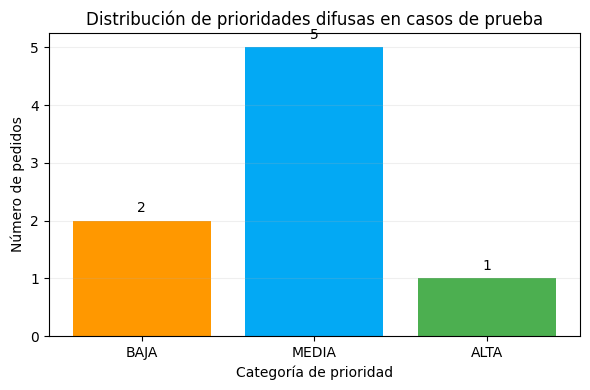

In [18]:
import matplotlib.pyplot as plt

conteo_prioridad = eval_df["prioridad_label"].value_counts().reindex(["BAJA", "MEDIA", "ALTA"]).fillna(0)

plt.figure(figsize=(6, 4))
bars = plt.bar(conteo_prioridad.index, conteo_prioridad.values, color=["#ff9800", "#03a9f4", "#4caf50"])
plt.title("Distribución de prioridades difusas en casos de prueba")
plt.xlabel("Categoría de prioridad")
plt.ylabel("Número de pedidos")
plt.grid(axis="y", alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.1, int(height), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [15]:
parsed, answer = process_message("quiero pedir PROD-003 cantidad 2", cliente="test_cliente", chat_id="test_chat_id")
print(parsed)
print("---")
print(answer)

intencion='crear_pedido' order_id='' producto_id='PROD-003' cantidad=2
---
Tu pedido test_cliente8241abfb fue procesado correctamente.
Producto: Rollo de etiqueta térmica 100x100
Cantidad: 2
Total: 64000
Estado: DESPACHADO
Prioridad logística: ALTA
Puntaje difuso: 83.11


In [17]:
parsed, answer = process_message("consultar estado de mi ultimo pedido", cliente="test_cliente", chat_id="test_chat_id")
print(parsed)
print("---")
print(answer)

intencion='consultar_estado' order_id='' producto_id='' cantidad=0
---
Pedido test_cliente8241abfb
Producto: Rollo de etiqueta térmica 100x100
Cantidad: 2
Estado: DESPACHADO
Total: 64000
Fecha pedido: 2026-06-08 19:56:18
Fecha despacho: 2026-06-08 19:56:18


## 8. Despliegue en Entorno de Red e Interfaz de Usuario
Este bloque configura los componentes asíncronos de la API de Telegram que exponen nuestro motor lógico al usuario final. Se estructuran los escuchadores de eventos para interceptar mensajes entrantes de forma concurrente, inyectar dinámicamente metadatos contextuales (nombre del cliente y `chat_id`) en nuestro orquestador central, e iniciar el bucle de ejecución continua en red. Con esto, el bot de control de stock y pedidos automatizados queda completamente operativo y disponible en tiempo real.

In [ ]:
from telegram import Update
from telegram.ext import ApplicationBuilder, CommandHandler, ContextTypes, MessageHandler, filters

async def start_command(update: Update, context: ContextTypes.DEFAULT_TYPE):
    await update.message.reply_text(
        "Hola, soy tu asistente de logística. Puedes escribir: quiero pedir PROD-003 cantidad 2"
    )

async def handle_message(update: Update, context: ContextTypes.DEFAULT_TYPE):
    if not update.message or not update.message.text:
        return

    mensaje = update.message.text
    cliente = update.effective_user.first_name or "Cliente"
    chat_id = str(update.effective_chat.id)

    try:
        parsed, answer = process_message(mensaje=mensaje, cliente=cliente, chat_id=chat_id)
        print("\n===== TRAZA DEL AGENTE =====")
        print("Mensaje:", mensaje)
        print("Estructura detectada:", parsed.model_dump())
        print("Respuesta final:", answer)
        await update.message.reply_text(answer)
    except Exception as e:
        await update.message.reply_text(f"Ocurrió un error procesando tu solicitud: {e}")


def build_telegram_app():
    app = ApplicationBuilder().token(TELEGRAM_BOT_TOKEN).build()
    app.add_handler(CommandHandler("start", start_command))
    app.add_handler(MessageHandler(filters.TEXT & ~filters.COMMAND, handle_message))
    return app

In [ ]:
app = build_telegram_app()
await app.initialize()
await app.start()
await app.updater.start_polling()

print("✅ Bot corriendo. Ahora envíale un mensaje desde Telegram.")

✅ Bot corriendo. Ahora envíale un mensaje desde Telegram.


In [ ]:
await app.updater.stop()
await app.stop()
await app.shutdown()

print("🛑 Bot detenido.")

🛑 Bot detenido.
